In [1]:
import torch
import torch.nn as nn
import numpy as np
import scipy
import matplotlib.pyplot as plt
from datetime import date
from torch.utils.tensorboard import SummaryWriter
%load_ext tensorboard
%rm -rf ./log/
%mkdir log
%tensorboard --logdir=log/ --host localhost --port 6008

In [2]:
DATA_PATH = 'Data/cylinder_nektar_wake.mat'
DATA_PATH_VORTICITY = 'Data/cylinder_nektar_t0_vorticity.mat'

## Network Definition

We start by defining the network architecture: 3 dimensional input and output, 4 hidden layers with 60 neurons and tanh activation

We then initialize two models, a naive model and a physics-informed model 

In [3]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 3),
        )
    
    def init_weights(self, m):
        if type(m) == nn.Linear:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        outputs = self.net(inputs)
        return outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3] # u, v,

model_pinn = PINN()
naive_model = PINN()


In [4]:
ns_wake_data = scipy.io.loadmat(DATA_PATH)

In [5]:
ns_vorticity = scipy.io.loadmat(DATA_PATH_VORTICITY)

In [6]:
ns_vorticity.keys()

dict_keys(['__header__', '__version__', '__globals__', 'modes', 'nel', 'w', 'x', 'y'])

In [7]:
ns_wake_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])

In [8]:
ns_wake_data['X_star'][0]

array([ 1., -2.])

In [9]:
ns_wake_data['U_star'].max()

np.float64(1.322556473239624)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import scipy.io
import numpy as np

def load_synthetic_data(file_path, N_train=10000):
    try:
        data = scipy.io.loadmat(file_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"No file {file_path} found.")

    # 2. Extract Raw Arrays
    # Assuming standard shapes: X_star (N, 2), t (T, 1), U_star (N, 2, T), P_star (N, T)
    t_star = data['t'].flatten()[:, None]  
    X_star = data['X_star']                
    U_star = data['U_star']                
    P_star = data['p_star']                

    N_spatial = X_star.shape[0]
    N_time = t_star.shape[0]

    # 3. Spatiotemporal Flattening (Meshgrid analog)
    # Tile the spatial coordinates for every time step
    x_flat = np.tile(X_star[:, 0:1], (1, N_time)).flatten()[:, None]
    y_flat = np.tile(X_star[:, 1:2], (1, N_time)).flatten()[:, None]
    
    # Repeat the time coordinates for every spatial point
    t_flat = np.repeat(t_star, N_spatial, axis=0)

    # Flatten the velocity and pressure fields correspondingly
    u_flat = U_star[:, 0, :].flatten()[:, None]
    v_flat = U_star[:, 1, :].flatten()[:, None]
    p_flat = P_star.flatten()[:, None]

    # 4. Stochastic Subsampling
    # We select N_train points randomly to serve as our empirical supervision anchors
    total_points = x_flat.shape[0]
    idx = np.random.choice(total_points, N_train, replace=False)

    # 5. Conversion to PyTorch Tensors
    to_tensor = lambda arr: torch.tensor(arr[idx, :], dtype=torch.float32)
    
    training_tensors = {
        'x': to_tensor(x_flat),
        'y': to_tensor(y_flat),
        't': to_tensor(t_flat),
        'u': to_tensor(u_flat),
        'v': to_tensor(v_flat),
        'p': to_tensor(p_flat)
    }
    
    print(f"Data parsed successfully. Subsampled {N_train} points from a total of {total_points}.")
    return training_tensors


training_data = load_synthetic_data(DATA_PATH)

Data parsed successfully. Subsampled 10000 points from a total of 1000000.


In [11]:
def compute_navier_stokes_residual(model, x, y, t, nu=0.01):
    """
    Evaluates the physical constraint violations (residuals) of the governing PDEs.
    """
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    
    u, v, p = model(x, y, t)
    
    # First-order derivatives
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    
    v_t = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]
    
    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]
    
    # Second-order derivatives (Kinematic viscosity diffusion)
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]
    
    # Governing Equations
    f_u = u_t + u * u_x + v * u_y + p_x - nu * (u_xx + u_yy) # x-momentum
    f_v = v_t + u * v_x + v * v_y + p_y - nu * (v_xx + v_yy) # y-momentum
    f_c = u_x + v_y                                          # continuity
    
    return f_u, f_v, f_c

## Training Loop

Standard training loop, get consecutive batches of training data and corresponding labels (velocity and pressure fields)

In [ ]:
def train_hybrid_pinn(pinn, naive_model, data, rate, epochs, batch, lambda_data = 1, lambda_pde = 1):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    print(f"Using device {device}")

    # send models and data to correct device
    pinn.to(device)
    naive_model.to(device)

    x, y, t = data['x'].to(device), data['y'].to(device), data['t'].to(device)
    u_true, v_true, p_true = data['u'].to(device), data['v'].to(device), data['p'].to(device)

    # initialize an optimizer for each model, one informed and one uninformed
    optimizer_1 = optim.Adam(pinn.parameters(), lr=rate)
    optimizer_2 = optim.Adam(naive_model.parameters(), lr=rate)
    epochs = epochs


    # set up loss history and tensorboard logger
    history = {"loss_naive": [], "loss_data_pinn": [], "loss_pde": [], "total_loss_pinn": []}
    tensorboard_hist = SummaryWriter(log_dir='log')
    
    for epoch in range(epochs):

        print(f"Epoch {epoch}")

        for batch_iter in range(int(len(x)/batch)):

            optimizer_1.zero_grad()
            optimizer_2.zero_grad()

            x_batch = x[epoch*batch:batch_iter*(epoch+1)]
            y_batch = y[epoch*batch:batch_iter*(epoch+1)]
            t_batch = t[epoch*batch:batch_iter*(epoch+1)]

            u_batch_true = u_true[epoch*batch:batch_iter*(epoch+1)]
            v_batch_true = v_true[epoch*batch:batch_iter*(epoch+1)]
            p_batch_true = p_true[epoch*batch:batch_iter*(epoch+1)]

            
            #forward pass for both models on the same data
            u_pred_pinn, v_pred_pinn, p_pred_pinn = pinn(x_batch, y_batch, t_batch)
            u_pred_naive, v_pred_naive, p_pred_naive = naive_model(x_batch, y_batch, t_batch)
            
            #compute data loss on informed model
            loss_data_pinn = torch.mean((u_pred_pinn - u_batch_true)**2) + \
                        torch.mean((v_pred_pinn - v_batch_true)**2) + \
                        torch.mean((p_pred_pinn - p_batch_true)**2)
            
            #compute data loss on uninformed model
            loss_data_naive = torch.mean((u_pred_naive - u_batch_true)**2) + \
                        torch.mean((v_pred_naive - v_batch_true)**2) + \
                        torch.mean((p_pred_naive - p_batch_true)**2)
                        
            #compute physical loss term (only for pinn)
            f_u, f_v, f_c = compute_navier_stokes_residual(pinn, x, y, t)
            
            loss_pde = torch.mean(f_u**2) + torch.mean(f_v**2) + torch.mean(f_c**2)
            
            #compute total loss for pinn
            loss_total = (lambda_data * loss_data_pinn) + (lambda_pde * loss_pde)
            
            #backpropagate total loss for pinn
            loss_total.backward()
            optimizer_1.step()

            #backpropagate only data loss for naive model
            loss_data_naive.backward()
            optimizer_2.step()

        history['loss_naive'].append(loss_data_naive.item())
        history['loss_data_pinn'].append(loss_data_pinn.item())
        history['loss_pde'].append(loss_pde.item())
        history['total_loss_pinn'].append(loss_total.item())

        tensorboard_hist.add_scalar("losses/Naive Model Data Loss", loss_data_naive.item(), epoch)
        tensorboard_hist.add_scalar("losses/Pinn Model Data Loss", loss_data_pinn.item(), epoch)
        tensorboard_hist.add_scalar("losses/PDE/Residual Loss", loss_pde.item(), epoch)
        tensorboard_hist.add_scalar("losses/PINN Total Loss", loss_total.item(), epoch)
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:05d} | Total Loss: {loss_total.item():.4e} | "
                  f"Data Loss Naive: {loss_data_naive.item():.4e} | Data Loss PINN: {loss_data_pinn.item()} | PDE Loss: {loss_pde.item():.4e}")


    # plt.figure()
    # plt.plot(np.arange(len(history['loss_data_pinn'])), history['loss_data_pinn'], label = 'Supervised Loss PINN', color = 'blue')
    # plt.plot(np.arange(len(history['loss_pde'])), history['loss_pde'], label = 'PDE Residual Loss', color = 'red')
    # plt.plot(np.arange(len(history['loss_naive'])), history['loss_naive'], label = 'Supervised Loss NN', color = 'green')
    # plt.plot(np.arange(len(history['total_loss_pinn'])), history['total_loss_pinn'], label = 'Total Informed Loss', color = 'yellow')
    # plt.legend(loc = 'upper left')
    # plt.title('Supervised Loss History')
    # plt.ylabel('Loss Values Log Scale')
    # plt.xlabel('Training Epochs')
    # plt.yscale('log')
    # plt.show()
    
    print("Saving model weigths...")
    torch.save(pinn.state_dict(), "Models/pinn_model_weigths_run_"+str(date.today()))
    torch.save(naive_model.state_dict(), "Models/naive_model_weights_run_"+str(date.today()))


    return pinn, naive_model

Using device mps
Epoch 0
Epoch 00000 | Total Loss: 1.5171e-01 | Data Loss Naive: 1.4799e-01 | Data Loss PINN: 0.14779077470302582 | PDE Loss: 3.9213e-03
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
E

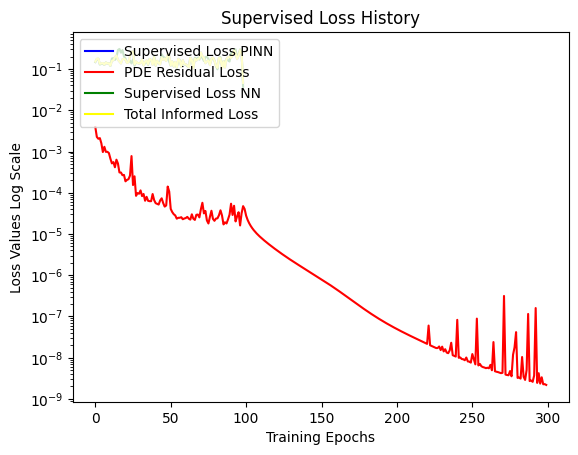

Saving model weigths...


In [13]:
trained_pinn, trained_naive = train_hybrid_pinn(pinn = model_pinn, naive_model = naive_model, data = training_data, rate = 1e-4, epochs = 300, batch = 100)

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_heatmap_comparison(model, data, device='mps', snapshot_idx=199):
    """
    Produces side-by-side heatmaps for the u-velocity component.
    Data shape: U_star (5000, 2, 200)
    Snapshot_idx: 199 corresponds to the 200th (final) time point.
    """
    model.eval()
    
    # 1. Coordinate Extraction (X: [1, 8], Y: [-2, 2])
    # Assuming data['x'] and data['y'] are (5000, 1) spatial coordinates
    x_raw = data['X_star'][:, 0:1].flatten()
    y_raw = data['X_star'][:, 1:2].flatten()
    
    # 2. Extract Ground Truth at the specific time snapshot
    # U_star shape is (5000, 2, 200) -> [spatial, component, time]
    # We take component 0 (u-velocity) at the requested snapshot_idx
    u_exact_raw = data['U_star'][:, 0, snapshot_idx].flatten()
    
    # Identify actual time if 't' vector exists
    actual_t = data['t'].flatten()[snapshot_idx] if 't' in data else snapshot_idx

    # 3. Create Structured Visualization Mesh
    res_x, res_y = 200, 100
    grid_x, grid_y = np.meshgrid(
        np.linspace(1.0, 8.0, res_x),
        np.linspace(-2.0, 2.0, res_y)
    )

    # 4. Interpolate Ground Truth onto the Mesh
    print(f"Interpolating Ground Truth at snapshot {snapshot_idx} (t={actual_t})...")
    u_exact_grid = griddata(
        (x_raw, y_raw), u_exact_raw, (grid_x, grid_y), method='cubic'
    )

    # 5. PINN/PI-KAN Inference
    # We query the model at the same high-resolution grid points
    x_test = torch.tensor(grid_x.flatten()[:, None], dtype=torch.float32).to(device)
    y_test = torch.tensor(grid_y.flatten()[:, None], dtype=torch.float32).to(device)
    t_test = torch.full_like(x_test, actual_t).to(device)

    with torch.no_grad():
        # Model returns (u, v, p)
        u_pred, _, _ = model(x_test, y_test, t_test)
    
    u_pred_grid = u_pred.cpu().numpy().reshape(res_y, res_x)

    # 6. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    cmap = 'jet'
    
    # Global scaling for rigorous comparison
    v_min = min(np.nanmin(u_exact_grid), np.nanmin(u_pred_grid))
    v_max = max(np.nanmax(u_exact_grid), np.nanmax(u_pred_grid))

    # Plot A: Ground Truth
    im0 = axes[0].contourf(grid_x, grid_y, u_exact_grid, levels=100, cmap=cmap, vmin=v_min, vmax=v_max)
    axes[0].set_title(f"Exact $u$-Velocity (Snapshot {snapshot_idx})", fontsize=15)
    axes[0].set_aspect('equal')
    axes[0].set_xlabel("$x$ [1, 8]")
    axes[0].set_ylabel("$y$ [-2, 2]")

    # Plot B: Model Prediction
    im1 = axes[1].contourf(grid_x, grid_y, u_pred_grid, levels=100, cmap=cmap, vmin=v_min, vmax=v_max)
    axes[1].set_title(f"Predicted $u$-Velocity ($u_\\theta$)", fontsize=15)
    axes[1].set_aspect('equal')
    axes[1].set_xlabel("$x$ [1, 8]")

    # Unified Colorbar
    fig.subplots_adjust(right=0.9)
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    fig.colorbar(im1, cax=cbar_ax, label="Velocity $u$")

    plt.show()

Interpolating Ground Truth at snapshot 80 (t=8.0)...


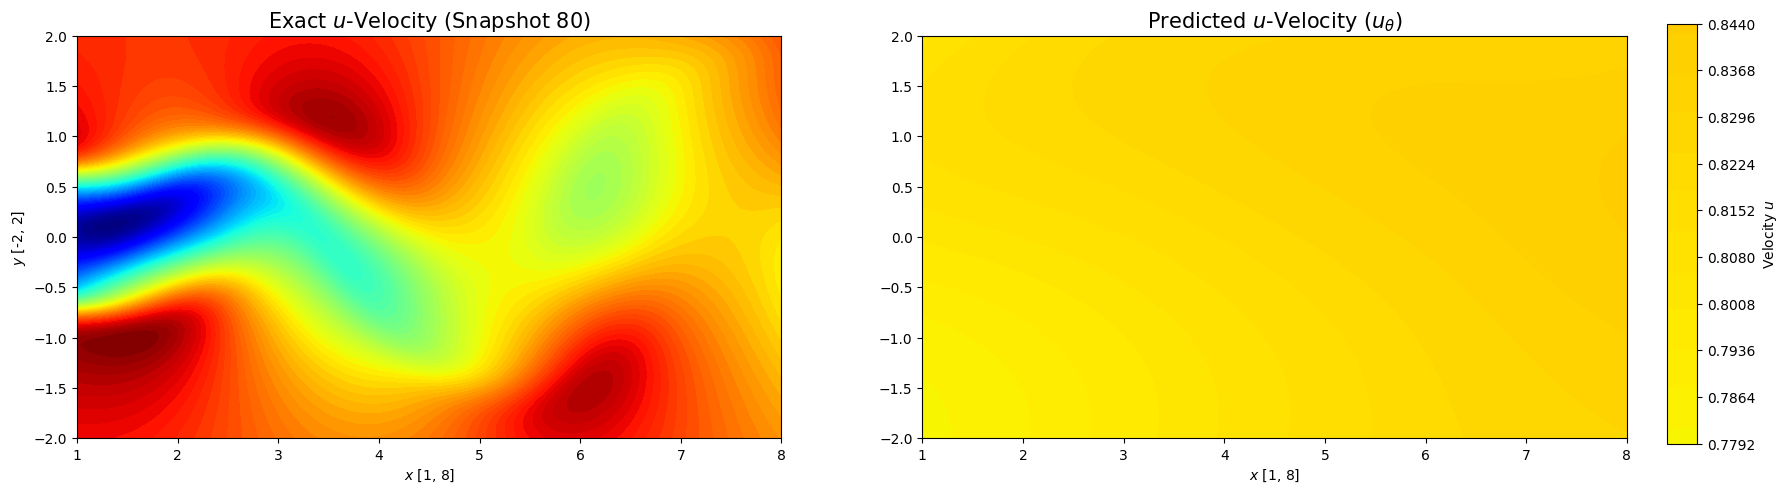

In [19]:
plot_heatmap_comparison(trained_pinn, ns_wake_data, snapshot_idx=80)

In [16]:
len(np.unique(ns_wake_data['X_star'][:, 0]))

100

In [17]:
ns_wake_data['X_star'][:, 0:1].shape

(5000, 1)